Environment setup

In [1]:
!pip install scikit-image gradio --quiet

In [2]:
import torch

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"GPUs: {torch.cuda.device_count()}")
print(f"Device: {DEVICE}")

GPUs: 2
Device: cuda


In [3]:
import random, numpy as np
import torch
from torch.amp import GradScaler

SEED = 42
random.seed(SEED) 
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True

scaler = GradScaler('cuda') 

Dataset download

In [4]:
import os

cuhk_photo_path  = "/kaggle/input/datasets/arbazkhan971/cuhk-face-sketch-database-cufs/photos"
cuhk_sketch_path = "/kaggle/input/datasets/arbazkhan971/cuhk-face-sketch-database-cufs/sketches"
anime_train_path = "/kaggle/input/datasets/ktaebum/anime-sketch-colorization-pair/data/train"
anime_val_path   = "/kaggle/input/datasets/ktaebum/anime-sketch-colorization-pair/data/val"

print(f"CUHK  — photos: {len(os.listdir(cuhk_photo_path))}  sketches: {len(os.listdir(cuhk_sketch_path))}")
print(f"Anime — train: {len(os.listdir(anime_train_path))}  val: {len(os.listdir(anime_val_path))}")

CUHK  — photos: 188  sketches: 188
Anime — train: 14224  val: 3545


Dataset class & DataLoaders

In [5]:
from torchvision import transforms

transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

In [7]:
from torch.utils.data import Dataset, DataLoader
from PIL import Image

In [8]:
class CUHKDataset(Dataset):
    def __init__(self, photo_dir, sketch_dir, transform=None):
        self.photos  = sorted([f for f in os.listdir(photo_dir)  if f.lower().endswith(('.jpg', '.png'))])
        self.sketches = sorted([f for f in os.listdir(sketch_dir) if f.lower().endswith(('.jpg', '.png'))])
        self.photo_dir  = photo_dir
        self.sketch_dir = sketch_dir
        self.transform  = transform

    def __len__(self):
        return len(self.photos)

    def __getitem__(self, idx):
        photo  = Image.open(os.path.join(self.photo_dir,  self.photos[idx])).convert("RGB")
        sketch = Image.open(os.path.join(self.sketch_dir, self.sketches[idx])).convert("RGB")
        if self.transform:
            photo  = self.transform(photo)
            sketch = self.transform(sketch)
        return sketch, photo


In [9]:
class AnimeDataset(Dataset):
    def __init__(self, data_dir, transform=None):
        self.files     = sorted([f for f in os.listdir(data_dir) if f.lower().endswith('.png')])
        self.data_dir  = data_dir
        self.transform = transform

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        img    = Image.open(os.path.join(self.data_dir, self.files[idx])).convert("RGB")
        w, h   = img.size
        sketch = img.crop((w//2, 0, w, h))  # right half = sketch
        color  = img.crop((0, 0, w//2, h))  # left half  = color
        if self.transform:
            sketch = self.transform(sketch)
            color  = self.transform(color)
        return sketch, color

In [10]:
cuhk_dataset  = CUHKDataset(cuhk_photo_path, cuhk_sketch_path, transform)
anime_train   = AnimeDataset(anime_train_path, transform)
anime_val     = AnimeDataset(anime_val_path,   transform)

In [11]:
cuhk_loader  = DataLoader(cuhk_dataset,  batch_size=16, shuffle=True,  num_workers=2, pin_memory=True)
anime_loader  = DataLoader(anime_train,   batch_size=16, shuffle=True,  num_workers=2, pin_memory=True)
anime_val_loader = DataLoader(anime_val, batch_size=16, shuffle=False, num_workers=2, pin_memory=True)

print(f"CUHK batches: {len(cuhk_loader)}")
print(f"Anime train batches: {len(anime_loader)} | Anime val batches: {len(anime_val_loader)}")


CUHK batches: 12
Anime train batches: 889 | Anime val batches: 222


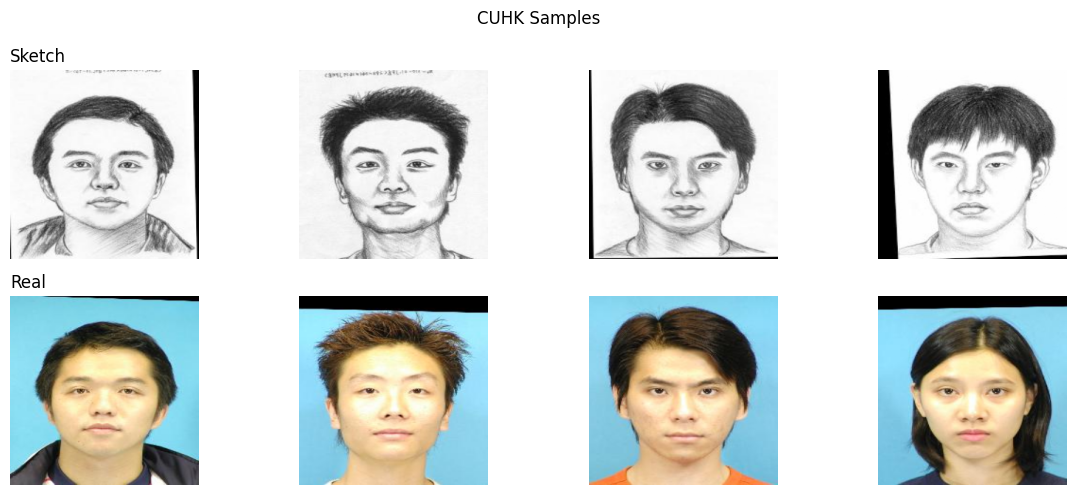

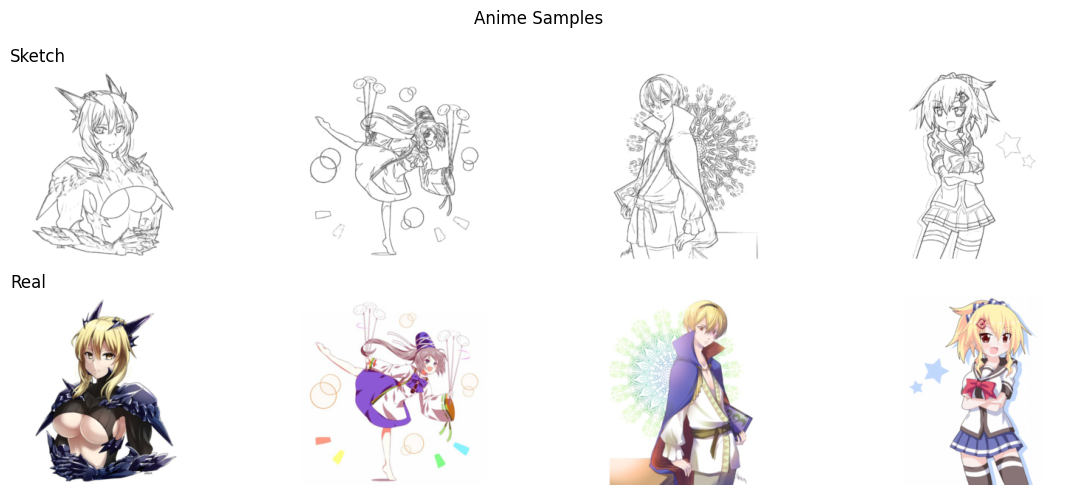

In [12]:
import matplotlib.pyplot as plt

def show_samples(loader, title, n=4):
    sketches, reals = next(iter(loader))
    fig, axes = plt.subplots(2, n, figsize=(12, 5))
    fig.suptitle(title)
    for i in range(n):
        for row, imgs in enumerate([sketches, reals]):
            img = imgs[i].permute(1,2,0).numpy() * 0.5 + 0.5
            axes[row, i].imshow(img.clip(0,1))
            axes[row, i].axis("off")
    axes[0, 0].set_title("Sketch", loc="left")
    axes[1, 0].set_title("Real",   loc="left")
    plt.tight_layout()
    plt.show()

show_samples(cuhk_loader,  "CUHK Samples")
show_samples(anime_loader, "Anime Samples")

Generator (U-Net)

In [15]:
import torch.nn as nn

class EncoderBlock(nn.Module):
    def __init__(self, in_ch, out_ch, normalize=True):
        super().__init__()
        layers = [nn.Conv2d(in_ch, out_ch, 4, 2, 1, bias=False)]
        if normalize:
            layers.append(nn.InstanceNorm2d(out_ch))
        layers.append(nn.LeakyReLU(0.2))
        self.block = nn.Sequential(*layers)

    def forward(self, x):
        return self.block(x)



In [16]:
class DecoderBlock(nn.Module):
    def __init__(self, in_ch, out_ch, dropout=False):
        super().__init__()
        layers = [
            nn.ConvTranspose2d(in_ch, out_ch, 4, 2, 1, bias=False),
            nn.InstanceNorm2d(out_ch),
            nn.ReLU()
        ]
        if dropout:
            layers.append(nn.Dropout(0.5))
        self.block = nn.Sequential(*layers)

    def forward(self, x, skip):
        x = self.block(x)
        return torch.cat([x, skip], dim=1)


In [19]:
class UNetGenerator(nn.Module):
    def __init__(self):
        super().__init__()
        self.e1 = EncoderBlock(3,   64,  normalize=False)
        self.e2 = EncoderBlock(64,  128)
        self.e3 = EncoderBlock(128, 256)
        self.e4 = EncoderBlock(256, 512)
        self.e5 = EncoderBlock(512, 512)
        self.e6 = EncoderBlock(512, 512)
        self.e7 = EncoderBlock(512, 512)
        self.e8 = EncoderBlock(512, 512, normalize=False)

        self.d1 = DecoderBlock(512,  512, dropout=True)   # out: 1024
        self.d2 = DecoderBlock(1024, 512, dropout=True)   # out: 1024
        self.d3 = DecoderBlock(1024, 512, dropout=True)   # out: 1024
        self.d4 = DecoderBlock(1024, 512)                 # out: 1024
        self.d5 = DecoderBlock(1024, 256)                 # out: 512
        self.d6 = DecoderBlock(512,  128)                 # out: 256
        self.d7 = DecoderBlock(256,  64)                  # out: 128

        self.out = nn.Sequential(
            nn.ConvTranspose2d(128, 3, 4, 2, 1),
            nn.Tanh()
        )

    def forward(self, x):
        e1 = self.e1(x)
        e2 = self.e2(e1)
        e3 = self.e3(e2)
        e4 = self.e4(e3)
        e5 = self.e5(e4)
        e6 = self.e6(e5)
        e7 = self.e7(e6)
        e8 = self.e8(e7)

        d1 = self.d1(e8, e7)
        d2 = self.d2(d1, e6)
        d3 = self.d3(d2, e5)
        d4 = self.d4(d3, e4)
        d5 = self.d5(d4, e3)
        d6 = self.d6(d5, e2)
        d7 = self.d7(d6, e1)

        return self.out(d7)


In [20]:
G = UNetGenerator().to(DEVICE)
test_input  = torch.randn(1, 3, 256, 256).to(DEVICE)
test_output = G(test_input)
print(f"Input:  {test_input.shape}")
print(f"Output: {test_output.shape}")

Input:  torch.Size([1, 3, 256, 256])
Output: torch.Size([1, 3, 256, 256])


Cell 5 — Discriminator (PatchGAN)

In [22]:
class PatchGANDiscriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.Conv2d(6,   64,  4, 2, 1, bias=False), nn.LeakyReLU(0.2),
            nn.Conv2d(64,  128, 4, 2, 1, bias=False), nn.InstanceNorm2d(128), nn.LeakyReLU(0.2),
            nn.Conv2d(128, 256, 4, 2, 1, bias=False), nn.InstanceNorm2d(256), nn.LeakyReLU(0.2),
            nn.Conv2d(256, 512, 4, 1, 1, bias=False), nn.InstanceNorm2d(512), nn.LeakyReLU(0.2),
            nn.Conv2d(512, 1,   4, 1, 1, bias=False)
        )

    def forward(self, sketch, target):
        x = torch.cat([sketch, target], dim=1)
        return self.model(x)


In [23]:
D = PatchGANDiscriminator().to(DEVICE)
sketch = torch.randn(1, 3, 256, 256).to(DEVICE)
target = torch.randn(1, 3, 256, 256).to(DEVICE)
print(f"Discriminator output shape: {D(sketch, target).shape}")

Discriminator output shape: torch.Size([1, 1, 30, 30])


Model init & DataParallel

In [24]:
def weights_init(m):
    if isinstance(m, (nn.Conv2d, nn.ConvTranspose2d)):
        nn.init.normal_(m.weight, 0.0, 0.02)


G.apply(weights_init)
D.apply(weights_init)


if torch.cuda.device_count() > 1:
    G = nn.DataParallel(G)
    D = nn.DataParallel(D)

print(f"Generator & Discriminator initialized with N(0, 0.02) on {torch.cuda.device_count()} GPU(s)")

Generator & Discriminator initialized with N(0, 0.02) on 2 GPU(s)


Losses & optimizers

In [25]:
import torch.optim as optim

# Losses
criterion_GAN = nn.BCEWithLogitsLoss()
criterion_L1  = nn.L1Loss()
LAMBDA        = 100

# Optimizers
opt_G = optim.Adam(G.parameters(), lr=0.0002, betas=(0.5, 0.999))
opt_D = optim.Adam(D.parameters(), lr=0.0002, betas=(0.5, 0.999))

print("Losses and optimizers ready.")

Losses and optimizers ready.


Training loop

In [27]:
from torch.amp import GradScaler
scaler = GradScaler("cuda")

In [28]:
G.load_state_dict(torch.load("/kaggle/working/checkpoints/G_epoch45.pth"))
D.load_state_dict(torch.load("/kaggle/working/checkpoints/D_epoch45.pth"))

start_epoch = 46

In [ ]:
from torch.amp import autocast
from tqdm import tqdm

EPOCHS = 50
checkpoint_dir = "/kaggle/working/checkpoints"
os.makedirs(checkpoint_dir, exist_ok=True)

G_losses, D_losses = [], []

for epoch in range(start_epoch, EPOCHS + 1):
    G_epoch_loss, D_epoch_loss = 0.0, 0.0

    for sketches, reals in tqdm(anime_loader, desc=f"Epoch {epoch}/{EPOCHS}"):
        sketches = sketches.to(DEVICE)
        reals    = reals.to(DEVICE)

        # ── Train Discriminator ──────────────────
        opt_D.zero_grad()
        with autocast("cuda"):
            fakes       = G(sketches)
            real_preds  = D(sketches, reals)
            fake_preds  = D(sketches, fakes.detach())
            loss_D_real = criterion_GAN(real_preds, torch.ones_like(real_preds))
            loss_D_fake = criterion_GAN(fake_preds, torch.zeros_like(fake_preds))
            loss_D      = (loss_D_real + loss_D_fake) * 0.5

        scaler.scale(loss_D).backward()
        scaler.step(opt_D)

        # ── Train Generator ──────────────────────
        opt_G.zero_grad()
        with autocast("cuda"):
            fake_preds  = D(sketches, fakes)
            loss_G_GAN  = criterion_GAN(fake_preds, torch.ones_like(fake_preds))
            loss_G_L1   = criterion_L1(fakes, reals) * LAMBDA
            loss_G      = loss_G_GAN + loss_G_L1

        scaler.scale(loss_G).backward()
        scaler.step(opt_G)
        scaler.update()

        G_epoch_loss += loss_G.item()
        D_epoch_loss += loss_D.item()

    G_losses.append(G_epoch_loss / len(anime_loader))
    D_losses.append(D_epoch_loss / len(anime_loader))
    print(f"Epoch [{epoch}/{EPOCHS}]  G: {G_losses[-1]:.4f}  D: {D_losses[-1]:.4f}")

    if epoch % 5 == 0:
        torch.save(G.state_dict(), f"{checkpoint_dir}/G_epoch{epoch}.pth")
        torch.save(D.state_dict(), f"{checkpoint_dir}/D_epoch{epoch}.pth")
        print(f" Checkpoint saved at epoch {epoch}")

Epoch 31/50: 100%|██████████| 889/889 [03:46<00:00,  3.92it/s]


Epoch [31/50]  G: 20.8629  D: 0.2935


Epoch 32/50: 100%|██████████| 889/889 [03:50<00:00,  3.86it/s]


Epoch [32/50]  G: 20.7489  D: 0.2872


Epoch 33/50: 100%|██████████| 889/889 [03:50<00:00,  3.86it/s]


...

Epoch 45/50: 100%|██████████| 889/889 [03:49<00:00,  3.88it/s]


Epoch [45/50]  G: 20.3644  D: 0.2747
 Checkpoint saved at epoch 45


Epoch 46/50: 100%|██████████| 889/889 [03:47<00:00,  3.91it/s]


Epoch [46/50]  G: 20.6162  D: 0.2614


Epoch 47/50:  72%|███████▏  | 640/889 [03:25<41:09,  9.92s/it]

In [29]:
from skimage.metrics import structural_similarity as ssim
from skimage.metrics import peak_signal_noise_ratio as psnr
import numpy as np
import torch
import torch.nn as nn

# Load best checkpoint
checkpoint_dir = "/kaggle/working/checkpoints"
G_eval = UNetGenerator().to(DEVICE)

# Load state dict and remove 'module.' prefix
state_dict = torch.load(f"{checkpoint_dir}/G_epoch45.pth")
from collections import OrderedDict
new_state_dict = OrderedDict()
for k, v in state_dict.items():
    name = k[7:] if k.startswith('module.') else k  # remove 'module.' prefix
    new_state_dict[name] = v

G_eval.load_state_dict(new_state_dict)
G_eval = nn.DataParallel(G_eval)  # Wrap after loading
G_eval.eval()

def evaluate(loader, name):
    ssim_scores, psnr_scores = [], []
    with torch.no_grad():
        for sketches, reals in loader:
            sketches = sketches.to(DEVICE)
            fakes    = G_eval(sketches)
            for i in range(len(fakes)):
                fake = (fakes[i].cpu().permute(1,2,0).numpy() * 0.5 + 0.5).clip(0,1)
                real = (reals[i].permute(1,2,0).numpy()       * 0.5 + 0.5).clip(0,1)
                ssim_scores.append(ssim(real, fake, channel_axis=2, data_range=1.0))
                psnr_scores.append(psnr(real, fake, data_range=1.0))
    print(f"{name} — SSIM: {np.mean(ssim_scores):.4f}  PSNR: {np.mean(psnr_scores):.4f} dB")

evaluate(anime_val_loader, "Anime Val")
evaluate(cuhk_loader,      "CUHK")

Anime Val — SSIM: 0.6457  PSNR: 14.6126 dB
CUHK — SSIM: 0.3928  PSNR: 8.4194 dB


In [31]:
def show_comparison(loader, title, n=8):
    sketches, reals = next(iter(loader))
    
    sketches = sketches.cpu()
    reals = reals.cpu()

    with torch.no_grad():
        fakes = G_eval(sketches.to(DEVICE)).cpu()

    fig, axes = plt.subplots(3, n, figsize=(16, 6))
    fig.suptitle(title)

    labels = ["Input Sketch", "Generated", "Ground Truth"]

    for i in range(n):
        for row, imgs in enumerate([sketches, fakes, reals]):
            img = (imgs[i].permute(1,2,0).numpy() * 0.5 + 0.5).clip(0,1)
            axes[row, i].imshow(img)
            axes[row, i].axis("off")

        axes[0, i].set_title(f"#{i+1}", fontsize=8)

    for row, label in enumerate(labels):
        axes[row, 0].set_ylabel(label, fontsize=9)

    plt.tight_layout()
    plt.show()

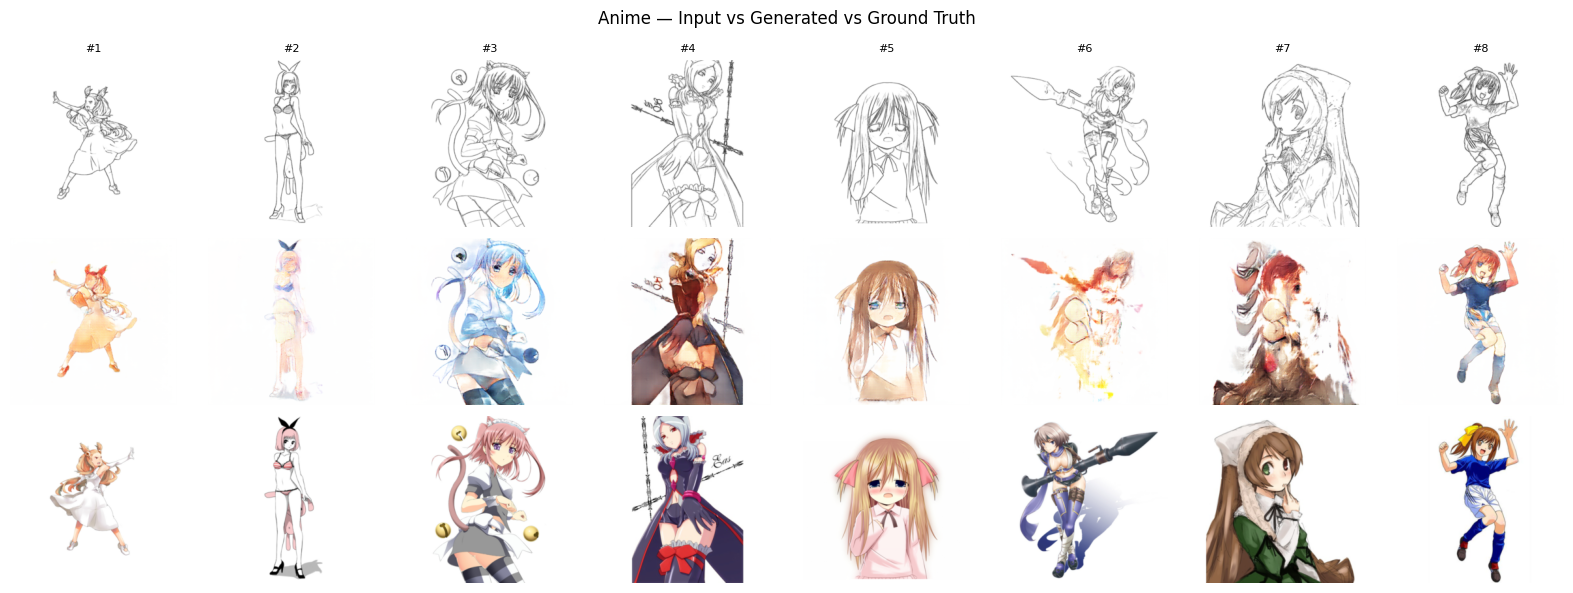

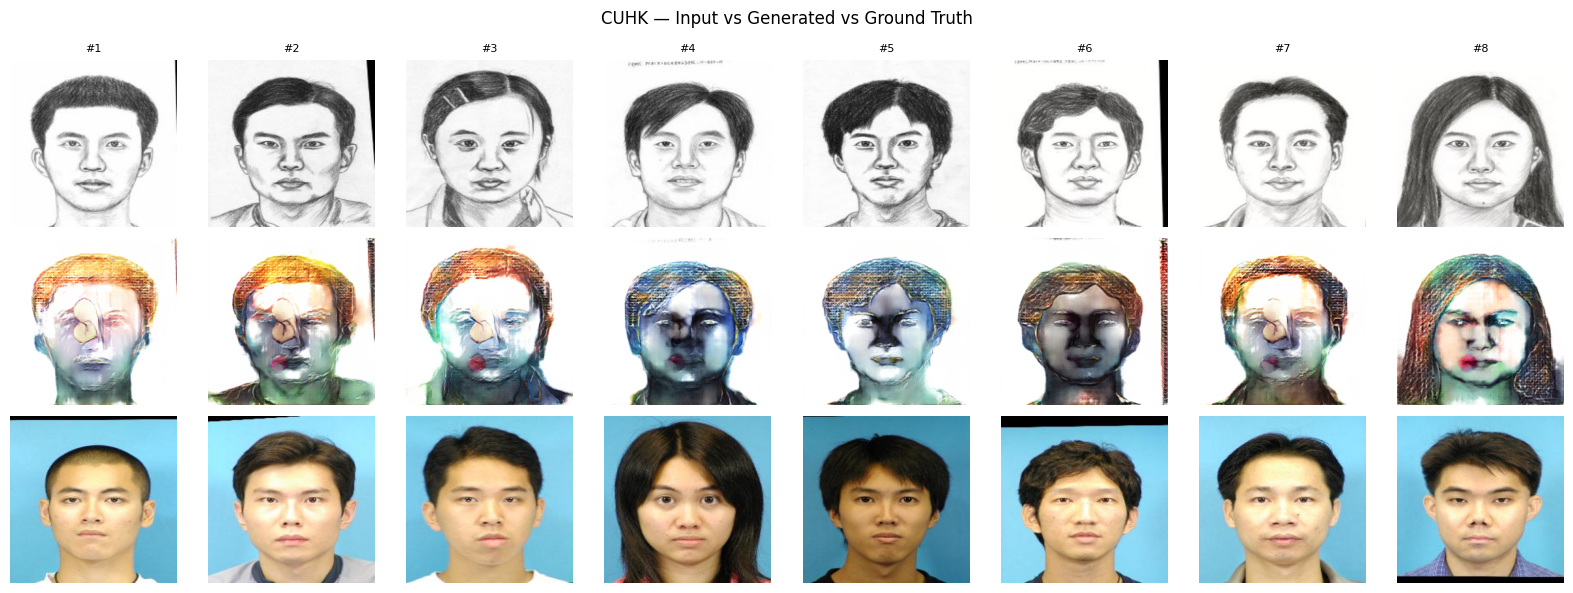

In [32]:
show_comparison(anime_val_loader, "Anime — Input vs Generated vs Ground Truth")
show_comparison(cuhk_loader,      "CUHK — Input vs Generated vs Ground Truth")

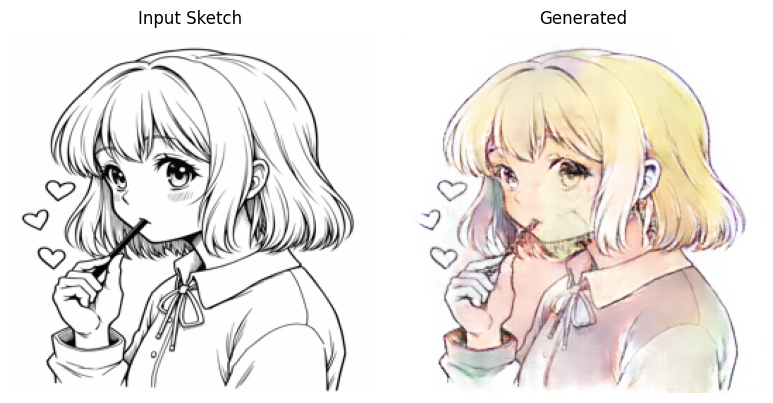

In [41]:
from PIL import Image
import torchvision.transforms as transforms

# put your image path here
input_image_path = "/kaggle/input/datasets/imranalinaeem/jdksjdkjs/s1.jpg"

img = Image.open(input_image_path).convert("RGB")

infer_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.ToTensor(),
    transforms.Normalize((0.5,0.5,0.5),(0.5,0.5,0.5))
])

sketch = infer_transform(img).unsqueeze(0).to(DEVICE)

G_eval.eval()
with torch.no_grad():
    output = G_eval(sketch)

output_img = (output[0].cpu().permute(1,2,0).numpy() * 0.5 + 0.5).clip(0,1)

plt.figure(figsize=(8,4))
plt.subplot(1,2,1); plt.imshow(img.resize((256,256))); plt.title("Input Sketch"); plt.axis("off")
plt.subplot(1,2,2); plt.imshow(output_img);             plt.title("Generated");    plt.axis("off")
plt.tight_layout(); plt.show()

In [43]:
import os
import shutil

checkpoint_dir = "/kaggle/working/checkpoints"

for f in sorted(os.listdir(checkpoint_dir)):
    src = os.path.join(checkpoint_dir, f)
    dst = os.path.join("/kaggle/working", f)
    shutil.copy2(src, dst)
    size = os.path.getsize(src) / (1024**2)
    print(f"{f}  —  {size:.1f} MB")

D_epoch10.pth  —  10.6 MB
D_epoch15.pth  —  10.6 MB
D_epoch20.pth  —  10.6 MB
D_epoch25.pth  —  10.6 MB
D_epoch30.pth  —  10.6 MB
D_epoch35.pth  —  10.6 MB
D_epoch40.pth  —  10.6 MB
D_epoch45.pth  —  10.6 MB
D_epoch5.pth  —  10.6 MB
G_epoch10.pth  —  207.5 MB
G_epoch15.pth  —  207.5 MB
G_epoch20.pth  —  207.5 MB
G_epoch25.pth  —  207.5 MB
G_epoch30.pth  —  207.5 MB
G_epoch35.pth  —  207.5 MB
G_epoch40.pth  —  207.5 MB
G_epoch45.pth  —  207.5 MB
G_epoch5.pth  —  207.5 MB
